#MTH 5000 – Applied Forecasting of Financial Data
##Lecture 10 & 11: Long Short-Term Memory (LSTM) networks
---
Topics

*  1. Feature Engineering
*  2. Building LSTM Model
*  3. Optimizer and Loss Function
*  4. Fitted vs. Predictied and Visualizations
*  5. Summary


Two-lecture structured introduction to time series forecasting using LSTMs.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Forecasting_Cleaned.csv to Forecasting_Cleaned (1).csv


In [ ]:
df = pd.read_csv("Forecasting_Cleaned.csv")
df.head()

,Date,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
0,2015-01-01,14.921,15.738,14.619,15.629,234334000,NaN,0.708,1.118,NaN
1,2015-01-08,14.663,15.157,14.325,15.016,375546000,-0.017,0.352,0.832,0.017
2,2015-01-15,14.863,15.300,14.262,14.700,420752000,0.014,-0.163,1.038,0.014
3,2015-01-22,15.196,15.847,15.000,15.000,380256000,0.022,-0.196,0.847,0.022
4,2015-01-29,18.237,18.391,14.967,15.236,1062542000,0.200,-3.001,3.425,0.200


In [ ]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

## 1. Feature Engineering

In [ ]:
# Feature Selection
features = ['Close','High','Low','Open','Volume',
            'Return','Open_Close_Diff','High_Low','Abs_Return']

data = df[features]

In [ ]:
scaler = MinMaxScaler() # MinMaxScaler rescales data to a fixed range (default: 0 to 1)

# Fit the scaler to the data AND transform it
# - fit(): learns the min and max values from your dataset
# - transform(): applies the scaling formula to each value
scaled_data = scaler.fit_transform(data)

Why this matters for LSTMs

Neural networks (especially LSTMs) train much better when inputs are:

on a similar scale
not dominated by large values

In [ ]:
# Sliding Window Sequence Creation
def create_sequences(data, seq_length=60):
    # Initialize empty lists to store input sequences (X) and targets (y)
    X, y = [], []

    # Loop over the dataset starting from index = seq_length
    # This ensures we always have enough previous data points to form a sequence
    for i in range(seq_length, len(data)):

        # Extract a sequence of length `seq_length`
        # This will be the input (features) for the model
        # Example: if seq_length = 60, this takes the previous 60 timesteps
        X.append(data[i-seq_length:i])

        # Take the value at time i as the target (label)
        # data[i, 0] means:
        #   - take the i-th row
        #   - take the first column (e.g., "Close" price if that's column 0)
        y.append(data[i, 0])

    # Convert lists to NumPy arrays for use in ML models (e.g., LSTM)
    return np.array(X), np.array(y)


# Create sequences from scaled data
X, y = create_sequences(scaled_data, 60)

# Print shapes:
# X shape = (num_samples, seq_length, num_features)
# y shape = (num_samples,)
X.shape, y.shape

((513, 60, 9), (513,))

In [ ]:
# Train-Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 2. Building LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Create a sequential model (layers are stacked one after another)
model = Sequential()

# First LSTM layer
model.add(LSTM(
    64,  # number of units (neurons) in this layer

    # return_sequences=True means:
    # this layer returns the full sequence (not just the last output)
    # needed because we are stacking another LSTM layer after this
    return_sequences=True,

    # input_shape = (timesteps, features)
    # X.shape[1] = sequence length (e.g., 60 days)
    # X.shape[2] = number of features (e.g., 1 if just "Close")
    input_shape=(X.shape[1], X.shape[2])
))

# Dropout layer (regularization)
# randomly drops 20% of neurons during training to prevent overfitting
model.add(Dropout(0.2))


# Second LSTM layer
model.add(LSTM(
    64  # 64 units again

    # return_sequences=False by default here:
    # this layer only returns the final output (not a sequence)
    # perfect before feeding into Dense layers
))

# Another dropout layer
model.add(Dropout(0.2))


# Fully connected (Dense) layer
model.add(Dense(
    32  # 32 neurons, helps learn complex patterns after LSTM
))


# Output layer
model.add(Dense(
    1  # single output value (e.g., next day's stock price)
))


# Compile the model
model.compile(
    optimizer='adam',  # adaptive learning rate optimizer (very common default)
    loss='mse'         # mean squared error (good for regression problems)
)


# Print a summary of the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,081 (211.25 KB)

 Trainable params: 54,081 (211.25 KB)

 Non-trainable params: 0 (0.00 B)

```
Input (60, 1)
   ↓
LSTM(64, return_sequences=True)
   ↓
Dropout(0.2)
   ↓
LSTM(64)
   ↓
Dropout(0.2)
   ↓
Dense(32)
   ↓
Dense(1)
```

In [ ]:
history = model.fit(
    X_train, y_train,  # training data (inputs and true outputs)

    epochs=20,         # how many times the model sees the entire training dataset
                       # (1 epoch = 1 full pass through X_train)

    batch_size=32,     # number of samples processed before updating model weights
                       # smaller batch = noisier but more general learning

    validation_data=(X_test, y_test)  # separate unseen data used to evaluate performance
                                       # after each epoch (no learning happens on this)
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - loss: 0.0327 - val_loss: 0.0353
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 0.0061 - val_loss: 0.0141
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0042 - val_loss: 0.0106
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0037 - val_loss: 0.0056
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0029 - val_loss: 0.0030
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0025 - val_loss: 0.0036
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0025 - val_loss: 0.0057
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0026 - val_loss: 0.0038
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0026 - val_loss: 0.0036
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0026 - val_loss: 0.0060
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0023 - val_loss: 0.0040
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 

## 3. Optimizer and Loss Function

## Model Compilation: Optimizer and Loss Function

Before training the model, we define:

* How the model learns (optimizer)
* What it tries to minimize (loss function)

Adam Optimizer

We use the Adam optimizer: optimizer = 'adam'


Adam stands for Adaptive Moment Estimation.

It is widely used because it:


* Automatically adjusts learning rates for each parameter
* Converges faster than standard gradient descent
* Combines: Momentum (smooth updates) and RMSProp (adaptive learning rates)

##Why Adam for LSTMs?

* Time series data is often noisy
* Gradients can be unstable
* Adam stabilizes and speeds up training

**Adam = fast + stable + low tuning effort**

## Mean Squared Error (MSE)

We use:

loss = 'mse'

Which equals $\mathrm{MSE} = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$


MSE measures the average squared difference between:

* Actual values: $y_i$
* Predicted values: $\hat{y}_i$

Why MSE is used

* This is a regression problem (predicting stock prices)
* Classification losses are not appropriate
* Squaring errors: Penalizes large errors more heavily and Encourages the model to reduce big mistakes


## Overall Learning Objective

The model aims to minimize prediction error over time:

$
\min \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$

| Aspect                     | Training Set                     | Validation Set                                   | Test Set                              |
| -------------------------- | -------------------------------- | ------------------------------------------------ | ------------------------------------- |
| **Purpose**                | Learn model parameters (weights) | Tune model & monitor performance during training | Final evaluation of model performance |
| **Used During Training?**  |  Yes                            |  No (only for evaluation during training)       |  No                                  |
| **Affects Model Weights?** |  Yes                            |  No                                             |  No                                  |
| **When Used**              | Every epoch                      | After each epoch (or periodically)               | Only once after training is complete  |
| **Helps With**             | Learning patterns                | Detecting overfitting / hyperparameter tuning    | Measuring real-world generalization   |
| **Example Metric**         | `loss`                           | `val_loss`                                       | `test_loss`                           |


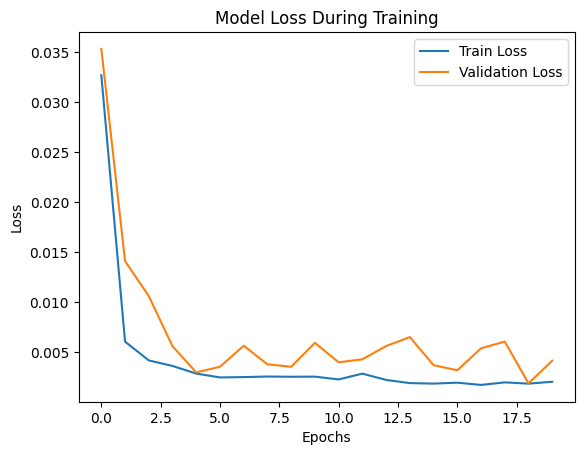

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')

if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Model Loss During Training")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

## 4. Fitted vs. Predictied and Visualizations

In [ ]:
pred = model.predict(X_test)

temp = np.zeros((len(pred), data.shape[1]))
temp[:,0] = pred[:,0]
predicted = scaler.inverse_transform(temp)[:,0]

temp2 = np.zeros((len(y_test), data.shape[1]))
temp2[:,0] = y_test
actual = scaler.inverse_transform(temp2)[:,0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step


In [ ]:
actual

array([151.71, 156.87, 155.2 , 170.53, 170.98, 168.59, 173.16, 173.51,
       176.56, 178.15, 179.83, 182.41, 185.95, 181.28, 176.59, 179.  ,
       188.  , 185.99, 183.13, 182.02, 181.28, 186.89, 182.81, 193.61,
       197.59, 199.79, 187.93, 180.83, 186.98, 162.77, 170.1 , 180.11,
       170.8 , 173.33, 184.52, 186.43, 192.53, 184.76, 185.17, 186.89,
       184.71, 192.73, 207.09, 214.1 , 202.88, 205.74, 218.16, 230.26,
       220.52, 229.05, 219.39, 222.13, 223.35, 235.01, 237.07, 236.17,
       228.93, 226.63, 214.35, 208.36, 198.89, 195.54, 201.13, 196.01,
       191.1 , 174.33, 180.6 , 184.42, 188.71, 210.25, 201.12, 204.72,
       207.23, 213.2 , 212.52, 211.99, 219.92, 222.54, 223.19, 228.29,
       230.19, 222.31, 224.56, 223.81, 229.12, 225.99, 230.33, 231.62,
       220.21, 220.63, 225.22, 215.57, 217.95, 230.3 , 250.2 , 244.2 ,
       222.69, 229.16, 232.38, 231.78, 221.27, 232.38, 232.53])

In [ ]:
predicted

array([149.96983066, 150.44005625, 152.03870251, 152.92532779,
       156.80591732, 160.19774965, 161.99604595, 163.98823624,
       166.03173945, 168.17115777, 170.15389976, 171.91965342,
       173.86036234, 175.94690942, 176.01935118, 174.8445032 ,
       176.1368444 , 178.64718977, 179.76933497, 179.8907451 ,
       179.75884776, 179.61765654, 180.75378468, 180.28982053,
       182.38324677, 184.74678528, 186.95544445, 184.42276287,
       180.84015322, 180.00609034, 170.41488661, 167.20187029,
       167.0623778 , 164.15566654, 163.82712354, 166.33192346,
       169.38576448, 173.01929395, 173.27738875, 174.90737028,
       176.69173979, 177.54394119, 180.15723528, 185.35859519,
       190.72497067, 190.8990555 , 192.49701385, 196.38870831,
       201.80826389, 202.86182809, 205.46118135, 204.64760152,
       205.4349142 , 206.87927077, 210.31782522, 213.77390047,
       216.46220546, 216.08733343, 215.78780925, 211.75276155,
       207.27740558, 202.21038581, 198.34929659, 197.64

In [ ]:
diff = actual - predicted
diff

array([  1.74016934,   6.42994375,   3.16129749,  17.60467221,
        14.17408268,   8.39225035,  11.16395405,   9.52176376,
        10.52826055,   9.97884223,   9.67610024,  10.49034658,
        12.08963766,   5.33309058,   0.57064882,   4.1554968 ,
        11.8631556 ,   7.34281023,   3.36066503,   2.1292549 ,
         1.52115224,   7.27234346,   2.05621532,  13.32017947,
        15.20675323,  15.04321472,   0.97455555,  -3.59276287,
         6.13984678, -17.23609034,  -0.31488661,  12.90812971,
         3.7376222 ,   9.17433346,  20.69287646,  20.09807654,
        23.14423552,  11.74070605,  11.89261125,  11.98262972,
         8.01826021,  15.18605881,  26.93276472,  28.74140481,
        12.15502933,  14.8409445 ,  25.66298615,  33.87129169,
        18.71173611,  26.18817191,  13.92881865,  17.48239848,
        17.9150858 ,  28.13072923,  26.75217478,  22.39609953,
        12.46779454,  10.54266657,  -1.43780925,  -3.39276155,
        -8.38740558,  -6.67038581,   2.78070341,  -1.63

In [ ]:
MSE = np.mean((predicted - actual)**2)
print(f"MSE: {MSE}")

MSE: 232.17725247415856


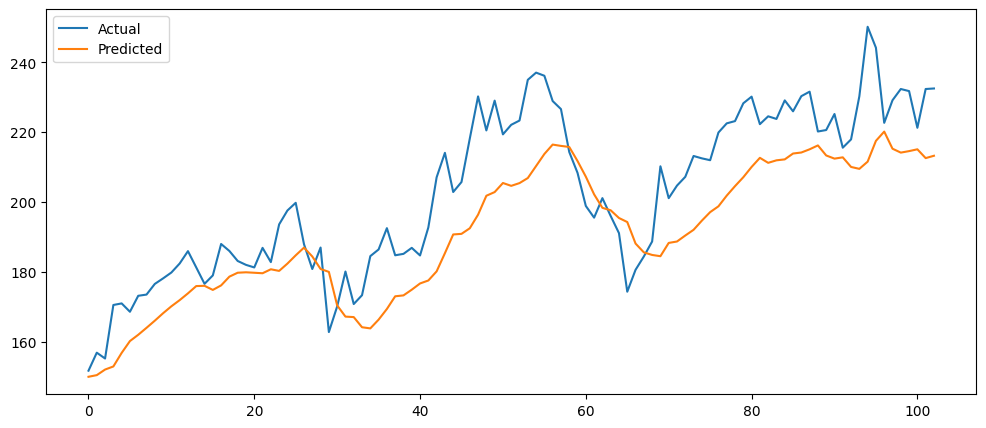

In [ ]:
# Prediction Plot
plt.figure(figsize=(12,5))
plt.plot(actual, label='Actual')
plt.plot(predicted, label='Predicted')
plt.legend()
plt.show()

## 5. Summary

- Adam optimizer controls how weights are updated
- MSE measures prediction error
- Training minimizes MSE using Adam

- LSTM learns temporal patterns
- Not a perfect predictor (markets are noisy)
- Requires scaling + sequence design
- Better for pattern learning than exact forecasting
